# OJ-Frost — a quantitative teardown 🔬
### Real OJ=F tape · freeze event study · the n=4 small-sample trap · placebo control · perfect-foresight ceiling · winter seasonality · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![The_Trading_Places_trade%3F: Busted](https://img.shields.io/badge/The_Trading_Places_trade%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run an event study around a hardcoded freeze table on the modern OJ futures tape, pin it against a random-date placebo, expose the small-sample fragility honestly, and bound the un-tradable ceiling.

> ⚠️ **Not investment advice.** Real data: Yahoo `OJ=F` continuous front-month FCOJ future, 2001–2026; as-of 2026-05-31 (partial June dropped); the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oj_frost import data, strategy as st

ASOF = pd.Timestamp("2026-05-31")

def _have_cache():
    return os.path.exists(data._cache_path("OJ=F", data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def load_oj():
    f = data.fetch_oj("OJ=F", fetch=False)
    return f[f.index <= ASOF]

print("real OJ=F cache present:", HAVE_REAL)


real OJ=F cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Only **n = 4** freezes in the tape; 5-day reactive mean **-240 bps** (win-rate 0%). The HAC *t* = -4.51 is a **degenerate small-sample artefact**, not evidence of an edge. Winter *t* = -1.36. |
| **Tradability** | `MIRAGE` | 8 of 12 lore freezes predate the tape; in-tape freezes go the wrong way; FCOJ is a thin, wide-spread contract. |
| **The *Trading Places* trade?** | `BUSTED` | Perfect-foresight ceiling (lag=0) still -360 bps (*t* = -3.83). No fill, fast or slow, recovers a pop. |

> 💡 In plain words: the famous trade is built on freezes the data doesn't contain; the four we can test all lost money over the following week; and the apparent *t*-stat is just four numbers that happened to share a sign — not a signal.

## 1 · The claim, steelmanned

Let $F$ be the set of severe Florida freeze dates and $r_{[1,w]}^{(e)}$ the OJ log-return over the $w$-session window starting one session **after** freeze $e$ (the reactive, look-ahead-free entry). The folklore + Roll (1984) channel gives:

- **H₁ (freeze pop).** $\mathbb{E}\big[r_{[1,w]}^{(e)} \mid e \in F\big] > 0$ and exceeds the same statistic on random non-freeze dates.
- **H₂ (it's capturable).** The forward window — the part you could actually trade after the cold night — is where the pop lives (not only the un-catchable freeze-day move).
- **H₃ (winter premium).** Dec–Feb daily returns exceed the rest of the year.

We find **H₁ rejected** (negative, and uncertifiable at n = 4), **H₂ rejected** (even the lag=0 ceiling is negative), and **H₃ rejected** (insignificant, wrong sign).

## 2 · So what? — what rides on each answer

The weather-to-price channel is genuinely documented (Roll 1984; Boudoukh et al. 2007), so the *interesting* content isn't 'does OJ react to freezes' — it's whether a **listable, tradable** rule on the **modern** tape banks anything. The decisive fact is a **survivorship-of-the-narrative** problem: the events that built the belief (8/12) are outside any retail data feed, and the remaining sample is far too small to certify a sign. Naming *why* the legend can't be tested is the product here, more than the (foregone) verdict.

## 3 · How we'd know — the protocol

- **Events.** Hardcoded `FREEZE_EVENTS` table of severe Florida freezes.
- **Entry.** First session at-or-after the freeze, then **lag = 1** (the documented execution lag — you act no sooner than the session after the cold night); hold $w$ sessions. A **lag = 0** 'perfect foresight' variant bounds the un-tradable ceiling.
- **Control.** A random-date placebo: the same $w$-window mean on thousands of random entry sessions — nets out OJ's ambient drift and the window length.
- **Inference.** Newey-West HAC *t* and a circular block-bootstrap CI — **reported with the loud caveat that at n = 4 neither is interpretable.**
- **Seasonality.** Dec–Feb vs rest-of-year daily mean, HAC *t* on a winter-dummy slope.
- **Positive control.** Deterministic synthetic tape with a front-loaded post-freeze spike — proves the engine *can* detect a freeze edge when one exists.

Tape: Yahoo `OJ=F`, 2001–2026, as-of 2026-05-31, gross (costs are moot with no edge).

## 4 · The teardown

### 4a · The sample problem — the legend is mostly un-testable

Before any statistic: how many freezes can the data even see?

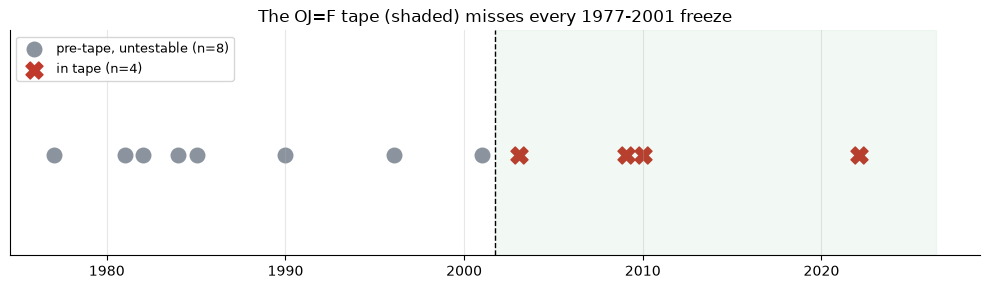

pre-tape: [1977, 1981, 1982, 1983, 1985, 1989, 1996, 2001]
in-tape: [2003, 2009, 2010, 2022]


In [2]:
fz = data.freeze_dates()
if HAVE_REAL:
    f = load_oj(); start, end = f.index.min(), f.index.max()
else:
    start, end = pd.Timestamp('2001-09-17'), pd.Timestamp('2026-05-29')
in_tape = fz[(fz >= start) & (fz <= end)]; pre = fz[fz < start]
fig, ax = plt.subplots(figsize=(10, 3.0))
ax.scatter(pre, [1]*len(pre), s=110, color=GREY, label=f'pre-tape, untestable (n={len(pre)})')
ax.scatter(in_tape, [1]*len(in_tape), s=150, color=RED, marker='X', label=f'in tape (n={len(in_tape)})')
ax.axvspan(start, end, color=GREEN, alpha=.06)
ax.axvline(start, ls='--', c='k', lw=1)
ax.set_yticks([]); ax.set_ylim(.6,1.5); ax.legend(loc='upper left', fontsize=9)
ax.set_title('The OJ=F tape (shaded) misses every 1977-2001 freeze')
plt.tight_layout(); plt.show()
print(f'pre-tape: {list(pre.year)}'); print(f'in-tape: {list(in_tape.year)}')

> 💡 In plain words: 8 of 12 freezes are outside the data. The *Trading Places*-era freezes — the ones that made the legend — are exactly the ones we can't touch. Any edge measured here rests on **four** events.

### 4b · The freeze event study vs the placebo — and the n=4 trap

The reactive (lag=1) window mean, by horizon, against the random-date placebo distribution. **The headline is the sample size, not the *t*-stat.**

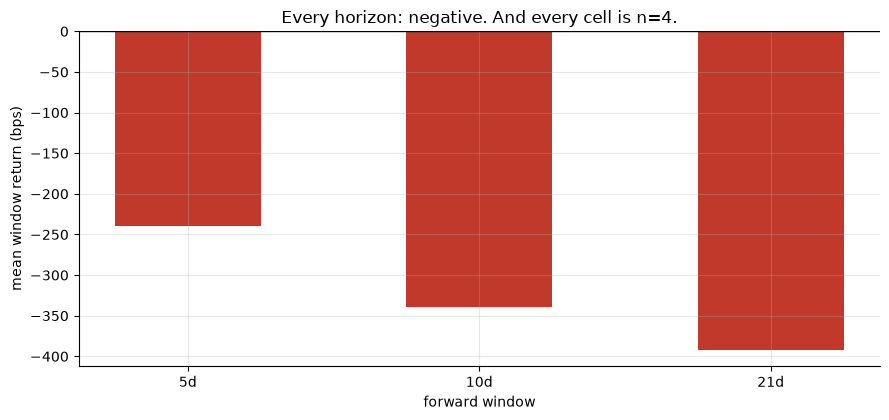

 window  n  win%  mean_bps  HAC_t  placebo_pct
      5  4   0.0   -239.55  -4.51        17.48
     10  4  25.0   -339.87  -1.85        16.78
     21  4  25.0   -392.33  -1.54        19.60


In [3]:
if HAVE_REAL:
    f = load_oj()
    rows = []
    for w in (5, 10, 21):
        led = st.window_returns(f, in_tape, window=w, lag=1)
        ctrl = st.random_control_windows(f, n_events=len(led), window=w, n_draws=5000)
        s = st.summarize_events(led, 'ret_gross', control_means=ctrl)
        rows.append((w, s['n_events'], s['win_rate']*100, s['mean_bps'], s['tstat'], s['placebo_pct']*100))
    tbl = pd.DataFrame(rows, columns=['window','n','win%','mean_bps','HAC_t','placebo_pct'])
else:
    tbl = pd.DataFrame({'window':[5,10,21],'n':[4,4,4],'win%':[0,25,25],
        'mean_bps':[-240,-340,-392],
        'HAC_t':[-4.51,-1.85,-1.54],'placebo_pct':[17,17,20]})
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(tbl['window'].astype(str)+'d', tbl['mean_bps'], color=RED, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean window return (bps)')
ax.set_xlabel('forward window'); ax.set_title('Every horizon: negative. And every cell is n=4.')
plt.tight_layout(); plt.show()
print(tbl.round(2).to_string(index=False))

> 💡 In plain words: the 5-day window's HAC *t* of **-4.51** looks decisive, but it is **four identically-signed numbers** — the block bootstrap collapses to a point and the asymptotic *t* is meaningless. This is the textbook MacKinlay (1997) small-sample failure. The honest statement is **no usable signal**, with the footnote that the scraps point the *wrong* way for the folklore. The freeze window sits around the 17th placebo percentile — not even unusual.

### 4c · The un-tradable ceiling — perfect foresight (lag=0)

Maybe the reactive lag throws away the pop? Bound it: enter on the freeze session itself (look-ahead — you don't yet know the crop damage, so this is a *ceiling*, not a strategy).

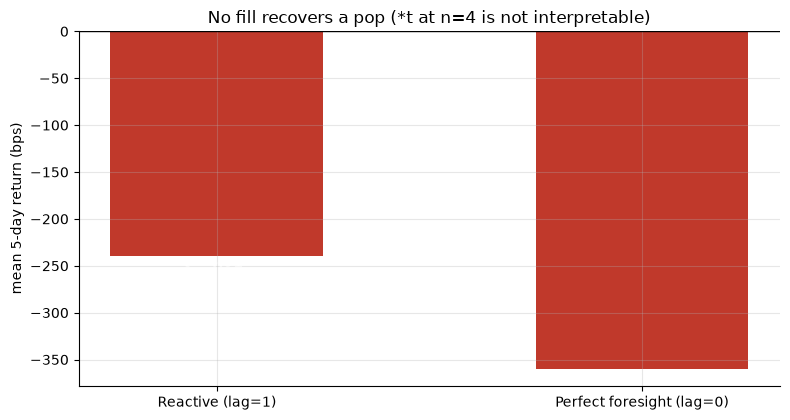

lag=1 -240 bps   lag=0 -360 bps


In [4]:
if HAVE_REAL:
    f = load_oj()
    s1 = st.summarize_events(st.window_returns(f, in_tape, window=5, lag=1), 'ret_gross')
    s0 = st.summarize_events(st.window_returns(f, in_tape, window=5, lag=0), 'ret_gross')
    vals, ts = [s1['mean_bps'], s0['mean_bps']], [s1['tstat'], s0['tstat']]
else:
    vals, ts = [-240, -360], [-4.51, -3.83]
fig, ax = plt.subplots(figsize=(8, 4.3))
b = ax.bar(['Reactive (lag=1)','Perfect foresight (lag=0)'], vals, color=[RED, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean 5-day return (bps)')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}*', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
                ha='center', va='top', color='white', fontweight='bold')
ax.set_title('No fill recovers a pop (*t at n=4 is not interpretable)')
plt.tight_layout(); plt.show()
print(f'lag=1 {vals[0]:+.0f} bps   lag=0 {vals[1]:+.0f} bps')

> 💡 In plain words: even cheating with perfect foresight the 5-day window is **-360 bps**. The pop is not a move you were too slow to capture — it isn't in the tape at all. H₂ rejected.

### 4d · Winter seasonality

The calendar version of the story: is OJ simply strong in the Dec–Feb freeze-risk season?

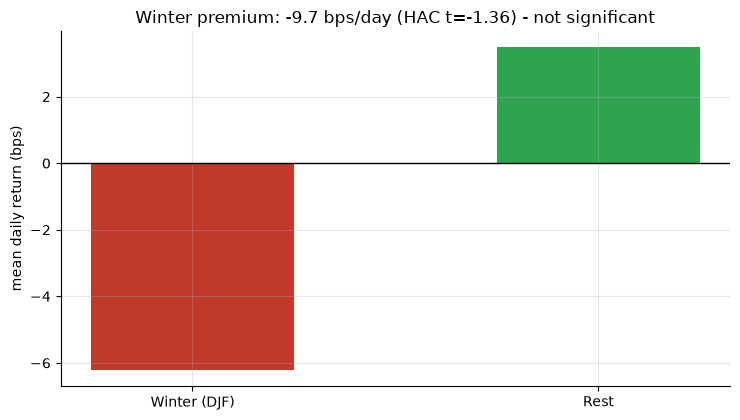

winter -6.2  rest +3.5  diff -9.7 bps/day  t=-1.36


In [5]:
if HAVE_REAL:
    ws = st.winter_seasonality(load_oj())
    w, o, diff, t = ws['winter_mean_bps'], ws['other_mean_bps'], ws['diff_bps'], ws['tstat']
else:
    w, o, diff, t = -6.2, 3.5, -9.7, -1.36
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['Winter (DJF)','Rest'], [w, o], color=[RED if w<0 else GREEN, GREEN if o>0 else RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Winter premium: {diff:+.1f} bps/day (HAC t={t:+.2f}) - not significant')
plt.tight_layout(); plt.show()
print(f'winter {w:+.1f}  rest {o:+.1f}  diff {diff:+.1f} bps/day  t={t:+.2f}')

> 💡 In plain words: the winter–rest difference is **-9.7 bps/day** at HAC *t* = **-1.36** — wrong sign, not significant. No seasonal trade. H₃ rejected.

## 5 · The verdict

- **Signal `NONE`** — n = 4 in-tape freezes, 5-day reactive mean -240 bps (win 0%). The HAC *t* = -4.51 is a degenerate n = 4 artefact, **not** a real (negative) edge; the freeze window isn't even unusual vs placebo (17th pct). Winter *t* = -1.36. Nothing certifiable.
- **Tradability `MIRAGE`** — 8/12 lore freezes predate the tape, the in-tape ones lose, and FCOJ is a thin, wide-spread contract. No edge, no capacity.
- **The *Trading Places* trade? `BUSTED`** — perfect-foresight ceiling -360 bps; no fill recovers a pop. The legend lives in untradable history.

## 6 · Could you trade it?

There is no positive edge to charge costs against, so the cost sweep is moot — but it's worth stating *why* even a hypothetical edge would struggle. FCOJ is one of the smallest, widest-spread futures markets; a realistic round-trip cost on a single-contract retail fill is large relative to a few-day move, and open interest caps size at a level that rules out meaningful capital. So the Tradability axis was `MIRAGE` **before** the Signal axis even reported: a thin contract, a four-event sample, and the famous freezes missing from the data. The candid bottom line: there is nothing here to size.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful freeze detector, or would it have missed a real pop? Plant a front-loaded post-freeze spike on a synthetic tape and sweep its size — the event study should light up cleanly when an effect is actually there (and stay quiet at zero).

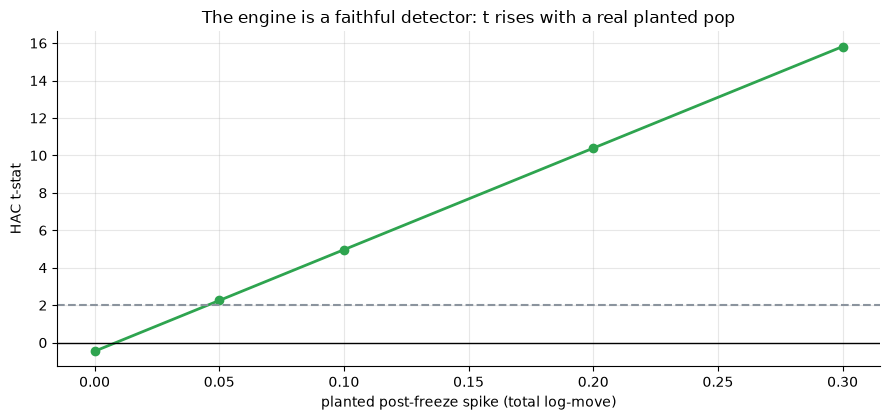

planted jump -> HAC t: [-0.46, 2.25, 4.96, 10.39, 15.81]
placebo percentile: [37, 96, 100, 100, 100]


In [6]:
jumps = [0.0, 0.05, 0.10, 0.20, 0.30]
tstats, placebos = [], []
for j in jumps:
    fr, tr = data.synthetic_oj(freeze_jump=j, seed=309)
    led = st.window_returns(fr, tr['syn_freezes'], window=5, lag=1)
    ctrl = st.random_control_windows(fr, n_events=len(led), window=5, n_draws=1000)
    s = st.summarize_events(led, 'ret_gross', control_means=ctrl)
    tstats.append(s['tstat']); placebos.append(s['placebo_pct']*100)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(jumps, tstats, 'o-', c=GREEN, lw=2, label='HAC t')
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted post-freeze spike (total log-move)'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine is a faithful detector: t rises with a real planted pop')
plt.tight_layout(); plt.show()
print('planted jump -> HAC t:', [round(t,2) for t in tstats])
print('placebo percentile:', [round(p) for p in placebos])

The engine cleanly detects a planted freeze pop (HAC *t* climbs through 2 as the spike grows; placebo percentile → 100), and is quiet at zero. So the real-tape null is a statement about **the market on this tape**, not a broken pipeline: with a 12-event synthetic the harness banks a real effect, while the real `OJ=F` tape offers only four freezes and no pop.

The right next experiment is a **pre-2001 FCOJ series** — the *Trading Places* era — where the legend was born. Until then, on the data a normal trader can pull, the freeze trade is a movie, not a market. See [Study 281 — El-Nino](../../281-el-nino/) for the same fate met by another weather-to-markets story.